# **Model Overview: Discrete Choice Model for Affordable Housing Applications**

This notebook implements a **Bayesian discrete choice model** designed to understand how applicants from different demographic groups make decisions about applying to affordable housing opportunities. The model was developed as part of a collaboration with **CHAPA**, with the goal of providing a transparent, data-driven way to study equity and access in lottery application patterns.

Rather than simply predicting who applies, the model aims to **quantify how different applicant characteristics and property attributes influence the probability of applying**, and how these relationships differ across racial and ethnic groups.

---

## **What the Model Does**

At a high level, the model represents each applicant’s decision to apply (or not apply) as a function of:

* **Applicant characteristics**

  * Age
  * Disability status
  * Household size
  * Number of dependents
  * Household income

* **Property characteristics**

  * Maximum resale price
  * Distance from the applicant’s home to the property

* **Demographic group**

  * The model allows each racial or ethnic group to have its own set of coefficients, capturing potential differences in how various factors shape application decisions.

These inputs are combined to form a **utility score**, which is then passed through a logistic (sigmoid) function to obtain the **probability of application** for each applicant–property pair.

The model is fully probabilistic: it does not output single estimates, but **posterior distributions**, giving us uncertainty intervals around all effects.

---

## **Why This Model Works**

Discrete choice models are widely used in economics and policy analysis because they mirror the way real decisions are made. The intuition is simple:

1. Each applicant receives a “utility” from each property, based on its features and their own characteristics.
2. Utility is modeled as a linear combination of effects (e.g., how income interacts with resale price).
3. Random variation is captured through applicant-level uncertainty.
4. The higher the utility, the more likely the applicant is to apply.

This Bayesian formulation offers several advantages:

* **Hierarchical race-specific effects**:
  In *Model 2*, Each racial/ethnic group gets its own set of coefficients, allowing us to examine heterogeneity without overfitting.

* **Partial pooling**:
  The model shrinks extreme subgroup estimates toward the overall mean, improving robustness when some groups have fewer observations.

* **Uncertainty quantification**:
  Instead of a single point estimate, the model provides a distribution for each effect.

* **Applicant-level variability**:
  A random effect (if computationally feasible) absorbs unobserved applicant differences (e.g., motivation, access to information), reducing bias in the fixed effects.

---

## **What Questions This Model Can Answer**

This model can support a wide range of fairness, equity, and program-design questions, including:

### **1. How do different factors influence the probability of applying?**

For example:

* Does household income make applicants more or less likely to apply to higher-priced properties?
* How does distance affect application likelihood?
* How much does disability status increase or reduce the probability of applying?

### **2. Do these effects differ across racial or ethnic groups?**

The hierarchical structure allows us to estimate:

* Which factors matter most for each group
* Where differences between groups are credible vs. driven by noise
* Whether systemic barriers may be impacting certain groups disproportionately

### **3. What is the probability that a specific type of applicant would apply?**

You can simulate:

* A high-income applicant vs. a low-income applicant
* Applicants with vs. without dependents
* Older vs. younger applicants

### **4. How sensitive are application rates to changes in policy or outreach?**

Because the model produces a utility function, you can run counterfactuals like:

* How would applications change if properties had lower resale prices?
* If transportation access improved and distance effectively decreased?
* If outreach increased awareness among groups with lower baseline application probabilities?

### **5. Can we identify where access gaps exist?**

By comparing group-specific coefficients, we can highlight where certain groups face structural disadvantages in the application process.



In [1]:
# import packages

# Data Wrangling
import numpy as np
import pandas as pd
import os

# Bayesian Methods
import pymc as pm
import arviz as az

# visualization
import matplotlib.pyplot as plt
az.style.use("arviz-darkgrid")

# update working directory
os.chdir("..")

# import data
dt = pd.read_parquet("data/processed/applications_clean.parquet")

# Creating our Discrete Choice Dataset

In [2]:
# some quick data cleaning

# if 'disabled'/'yes' -> 1; 0 otherwise.
dt['Disability'] = dt['Disability'].isin(["Disabled", "Yes"]).astype(int)

# if NA -> 0
dt['Dependents'] = dt['Dependents'].fillna(0)

# if HH Income missing, drop
dt = dt.dropna(subset = ['HH Income'])

# if HH Assets missing, drop ???
# dt = dt.dropna(subset = ['HH Assets'])

# Impute Age conditional on Income and number of Dependents
def impute_age(df):

    dt['IncomeBin'] = pd.qcut(
        dt['HH Income'],
        q = [0, 0.2, 0.4, 0.6, 0.8, 1],
        labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
)
    
    # compute group medians
    group_medians = (
        df.groupby(['IncomeBin', 'Dependents'])['Age']
        .median()
        .rename('Age_median')
    )
    
    # merge medians back to df
    df = df.merge(group_medians, on=['IncomeBin', 'Dependents'], how='left')
    
    # impute
    df['Age'] = df['Age'].fillna(df['Age_median'])
    
    # drop helper column
    return df.drop(columns=['Age_median'])

dt = impute_age(dt)


def collapse_race(raw):
    """
    Per current OMB rules.
    """

    r = raw.lower()

    # Hispanic supersedes
    if "hispanic" in r:
        return "Hispanic/Latino"

    # Unknown / prefer not to answer
    if "unknown" in r or "choose" in r or "not" in r:
        return "Unknown"

    # Single-race categories
    if r == "white" or r == "white_mena":
        return "White"
    if "black_african_american" in r and "/" not in r:
        return "Black"
    if r == "asian":
        return "Asian"
    if r == "native_american_alaskan_native":
        return "Native American"

    # Multi-race (non-Hispanic)
    if "/" in r:
        return "Two or More Races"

    # Fallback
    return "Unknown"

dt["race_norm_final"] = dt["race_norm_final"].apply(collapse_race)

# rename applicant current residence lat/lon
dt = dt.rename({'longitude': 'applicant_longitude', 'latitude': 'applicant_latitude'}, axis=1)

/var/folders/q9/vssjztfs6gd47qy2w2t2f0t80000gn/T/ipykernel_41933/2469080535.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['IncomeBin', 'Dependents'])['Age']


In [ ]:
# unique applicants
app_dt = (dt
          .groupby("ID Number")[['Age', 'Disability', 
                                 'HH Size', 'Dependents', 
                                 'race_norm_final', 
                                 'HH Income', 'HH Assets', 
                                 'applicant_MTSP_Income_Limit',
                                 'applicant_longitude', 'applicant_latitude']].last()).reset_index()

# unique properties
prop_dt = dt[['Application Property', 'Property Maximum Resale Price', 'property_latitude', 'property_longitude']].drop_duplicates().dropna()

# creating cartesian product dataset
choice_dt = pd.merge(app_dt, prop_dt, how='cross')

# create 'applied' binary outcome variable
applied_dt = pd.concat(
    (dt[["ID Number", "Application Property"]], 
     pd.Series( np.ones(len(dt)), name="applied")
     ), axis=1)

# merge using cart-product
choice_dt = choice_dt.merge(applied_dt, on=["ID Number", "Application Property"], how="left")


# find distance in miles
choice_dt["distance_miles"] = 3958.8 * 2 * np.arcsin(
    np.sqrt(
        np.sin(np.radians(choice_dt["property_latitude"] - choice_dt["applicant_latitude"]) / 2) ** 2
        + np.cos(np.radians(choice_dt["applicant_latitude"]))
        * np.cos(np.radians(choice_dt["property_latitude"]))
        * np.sin(np.radians(choice_dt["property_longitude"] - choice_dt["applicant_longitude"]) / 2) ** 2
    )
)

choice_dt["applied"] = choice_dt["applied"].fillna(0)
choice_dt = choice_dt.drop(['applicant_latitude', 'applicant_longitude', 'property_latitude', 'property_longitude'], axis=1)

# TO-DO: NEED BETTER SOLUTION HERE
choice_dt = choice_dt.dropna(subset="distance_miles")

# High household size taming (is this a good fallback value??)
choice_dt.loc[(choice_dt['HH Size']>8), 'HH Size'] = 0
# Alternative: -- accounts for 60% of answers correctly.
# choice_dt.loc[(choice_dt['HH Size']>8), 'HH Size'] = choice_dt.loc[(choice_dt['HH Size']>8), 'Dependents'] + 1

choice_dt.describe()

,ID Number,Age,Disability,HH Size,Dependents,HH Income,HH Assets,applicant_MTSP_Income_Limit,Property Maximum Resale Price,applied,distance_miles
count,138781.000000,138781.000000,138781.000000,138781.000000,138781.000000,1.387810e+05,137161.000000,127760.000000,138781.000000,138781.000000,138781.000000
mean,507439.637386,41.090084,0.066983,2.073267,0.548332,1.203145e+05,45495.000912,60314.898638,240674.258609,0.012343,36.010267
std,289296.522630,13.649327,0.249994,1.530713,0.860182,1.956038e+06,59531.148035,12271.125513,46420.441183,0.110413,21.543833
min,101.000000,0.000000,0.000000,0.000000,0.000000,7.000000e+01,0.000000,40050.000000,148438.000000,0.000000,0.000000
25%,247829.000000,31.000000,0.000000,1.000000,0.000000,5.200000e+04,14000.000000,52550.000000,204948.000000,0.000000,20.584763
50%,521641.000000,38.000000,0.000000,2.000000,0.000000,6.400000e+04,30733.890000,57900.000000,235200.000000,0.000000,32.617685
75%,750684.000000,49.000000,0.000000,3.000000,1.000000,7.700000e+04,59915.430000,66200.000000,273400.000000,0.000000,46.724262
max,998585.000000,86.000000,1.000000,31.000000,7.000000,7.020040e+07,863967.300000,160900.000000,374062.000000,1.000000,168.023139


# Model 1 Description
---

**Hyper-Priors**
$$ \text{Fixed Effects Priors: } \beta \sim \mathcal{N}(0,1) $$
$$ \text{Interaction Effects Priors: } \beta_{\text{int}} \sim \mathcal{N}(0,0.5) $$
$$ \text{Applicant Mean Prior: } \mu_{\text{app}} \sim \mathcal{N}(0,1) $$
$$ \text{Applicant Variance Prior: } \sigma_{\text{app}}^2 \sim \text{Half-Normal}(2) $$

---
**Applicant-Level Random Effects**

$$ \gamma_i \sim \mathcal{N}(\mu_{\text{app}}, \sigma_{\text{app}}^2) $$

---
**Utility**

$$ \eta_{ij} = \gamma_i + \mathbf{X_{ij}^T}\beta + \beta_{\text{int}}\mathbf{X_{\text{int}, i,j}} $$

$$ p_{ij} = \frac{1}{1+\text{exp}(-\eta_{ij})} $$

$$ Y_{ij} \sim \text{Bernoulli}(p_{ij}) $$

In [ ]:
X_FE = choice_dt[['Age', 'Disability', 'Race', 'HH Size', 'Dependents', 'HH Income', 'Property Maximum Resale Price', 'distance_miles']]
X_int = choice_dt['HH Income'] * choice_dt['Property Maximum Resale Price']
y_applied = choice_dt["applied"]

# Defining sizes
N_app = len(app_dt)
N_FE = len(X_FE.columns)
N_int = 1 #len(X_int.columns)
N_obs = len(X_FE)
app_idx = choice_dt['ID Number']

# transform dataframes to arrays
X_FE_arr = X_FE.values

# scale numeric columns
X_FE_arr[:,[0,3,4,5,6]]  = (X_FE_arr[:,[0,3,4,5,6]]  - X_FE_arr[:,[0,3,4,5,6]].mean(0))  / X_FE_arr[:,[0,3,4,5,6]].std(0)
X_int_arr = (X_int.values - X_int.values.mean(0)) / X_int.values.std(0)
X_int_arr = X_int_arr.reshape((-1,1))
y_arr = y_applied.values


with pm.Model() as model:

    # hyperpriors
    beta_fe = pm.Normal("beta_fe", mu=0, sigma=1, shape=N_FE)
    beta_int = pm.Normal("beta_int", mu=0, sigma=0.5, shape=N_int)
    mu_app = pm.Normal("mu_app", mu=0, sigma=1)
    sigma_app = pm.HalfNormal("sigma_app", sigma=2)

    # Applicant-level RE
    gamma_i = pm.Normal("gamma_i", mu=mu_app, sigma=sigma_app, shape=N_app)

    # Utility calculations
    gamma_for_obs = gamma_i[app_idx].reshape((-1,1))

    fixed_effects_term = X_FE_arr @ beta_fe.reshape((-1,1))
    interaction_term   = X_int_arr @ beta_int.reshape((-1,1))
    eta = gamma_for_obs + fixed_effects_term + interaction_term

    eta = eta.flatten() 
    
    p = pm.invlogit(eta)
    p_var = pm.Deterministic("p", p)

    Y = pm.Bernoulli("Y", p=p, observed=y_arr)

    idata = pm.sample(draws=200, chains=2, random_seed=42)


Initializing NUTS using advi+adapt_diag...


/Users/pavlomysak/opt/anaconda3/envs/chapa_env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Convergence achieved at 178400
Interrupted at 178,399 [89%]: Average Loss = 11,044
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta_fe, beta_int, mu_app, sigma_app, gamma_i]


/Users/pavlomysak/opt/anaconda3/envs/chapa_env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 200 draw iterations (2_000 + 400 draws total) took 444 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
# Generating sampled dataset
sampled_dt = idata.posterior.to_dataframe().reset_index()

In [ ]:
def reformat_sample_dt(sampled_dt):

    # creating wide-format posterior samples df

    # pivot beta_fe
    beta_fe_wide = (
        sampled_dt.pivot_table(
            index=["chain", "draw"],
            columns="beta_fe_dim_0",
            values="beta_fe"
        )
    )

    # rename columns
    beta_fe_wide.columns = [f"beta_fe[{i}]" for i in beta_fe_wide.columns]

    # pivot gamma_i
    gamma_i_wide = (
        sampled_dt.pivot_table(
            index=["chain", "draw"],
            columns="gamma_i_dim_0",
            values="gamma_i"
        )
    )

    gamma_i_wide.columns = [f"gamma_i[{i}]" for i in gamma_i_wide.columns]

    # pivot beta_int
    beta_int_wide = (
        sampled_dt.pivot_table(
            index=["chain", "draw"],
            columns="beta_int_dim_0",
            values="beta_int"
        )
    )

    beta_int_wide.columns = [f"beta_int[{i}]" for i in beta_int_wide.columns]

    # scalar params
    scalars = sampled_dt.drop_duplicates(subset=["chain","draw"])[["chain","draw","mu_app","sigma_app"]]
    scalars = scalars.set_index(["chain","draw"])

    # merge expanded data
    posterior_wide = (
        scalars
        .join(beta_fe_wide)
        .join(beta_int_wide)
        .join(gamma_i_wide)
    )

    return posterior_wide.sort_index().reset_index()

In [ ]:
posterior_wide = reformat_sample_dt(sampled_dt)

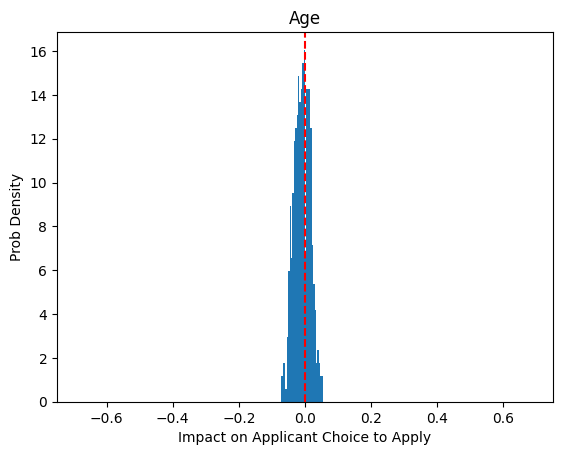

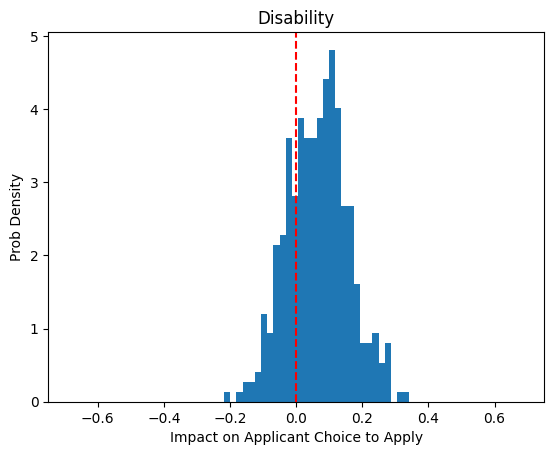

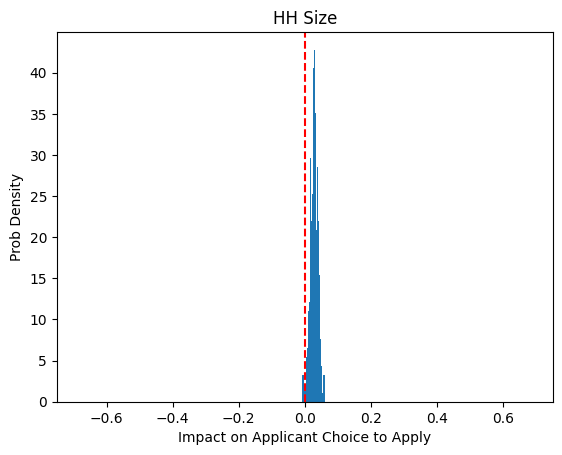

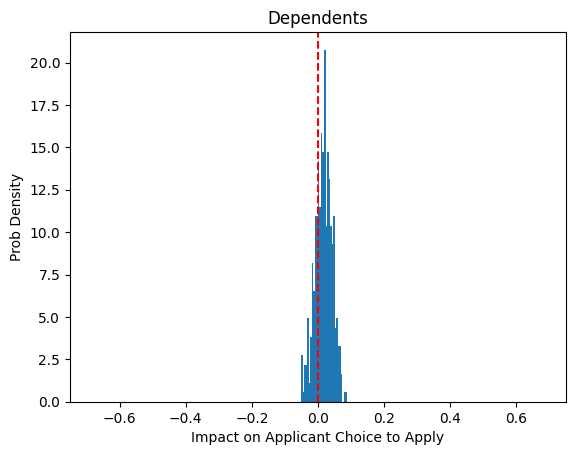

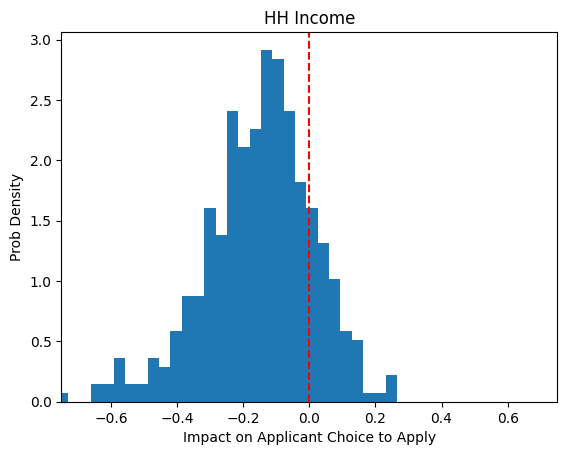

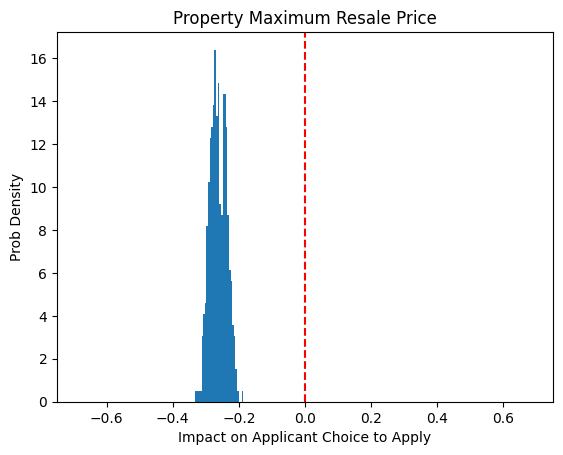

In [83]:
for fe in range(len(X_FE.columns)):

    plt.hist(posterior_wide[f"beta_fe[{fe}]"], density=True, bins=30)
    plt.axvline(x=0, color='red', linestyle='dashed')
    plt.xlim(-0.75,0.75)
    plt.title(X_FE.columns[fe])
    plt.ylabel("Prob Density")
    plt.xlabel("Impact on Applicant Choice to Apply")
    plt.show()


# Model 2 Description
---

**Hyper-Priors**
$$ \text{Fixed Effects Mean Hyper-prior: } \mu_\beta \sim \mathcal{N}(0,1) $$
$$ \text{Fixed Effects Variance Hyper-prior: } \sigma_\beta \sim \text{Exp}(1) $$

$$ \text{Fixed Effects Priors: } \beta_\text{race} \sim \mathcal{N}(\mu_\beta, \sigma_\beta) $$
$$ \text{Applicant Slope Mean Prior: } \mu_{\text{app}} \sim \mathcal{N}(0,1) $$
$$ \text{Applicant Slope Variance Prior: } \sigma_{\text{app}}^2 \sim \text{Half-Normal}(1) $$

---
**Intercept**

$$ \gamma \sim \mathcal{N}(\mu_{\text{app}}, \sigma_{\text{app}}^2) $$

---
**Utility**

$$ \eta_{ij} = \gamma + \mathbf{X_{ij}^T}\beta_\text{race} $$

$$ p_{ij} = \frac{1}{1+\text{exp}(-\eta_{ij})} $$

$$ Y_{ij} \sim \text{Bernoulli}(p_{ij}) $$

In [12]:
X_FE = choice_dt[['Age', 'Disability', 'HH Size', 'Dependents', 'HH Income', 'Property Maximum Resale Price', 'distance_miles']]
y_applied = choice_dt["applied"]

# Defining sizes
N_app = len(app_dt)
N_FE = len(X_FE.columns)
race_idx = choice_dt["race_norm_final"].astype("category").cat.codes.values
N_race = choice_dt["race_norm_final"].nunique()
N_obs = len(X_FE)
app_idx = choice_dt['ID Number']

# transform dataframes to arrays
X_FE_arr = X_FE.values

# scale numeric columns
X_FE_arr[:,[0,3,4,5,6]]  = (X_FE_arr[:,[0,3,4,5,6]]  - X_FE_arr[:,[0,3,4,5,6]].mean(0))  / X_FE_arr[:,[0,3,4,5,6]].std(0)
y_arr = y_applied.values


with pm.Model() as model:

    X_data = pm.Data("X_data", X_FE_arr)
    race_idx_data = pm.Data("race_idx", race_idx)
    app_idx_data = pm.Data("app_idx", app_idx)
    y_data = pm.Data("y_data", y_arr)

    # hyperpriors
    mu_beta = pm.Normal("mu_beta", 0, 1, shape=N_FE)
    sigma_beta = pm.Exponential("sigma_beta", 1)
    beta_fe = pm.Normal("beta_fe", mu=mu_beta, sigma=sigma_beta, shape=(N_race, N_FE))

    mu_app = pm.Normal("mu_app", mu=0, sigma=1)
    sigma_app = pm.HalfNormal("sigma_app", sigma=2)

    # Applicant-level RE (too computationally expensive)
    #gamma_i = pm.Normal("gamma_i", mu=mu_app, sigma=sigma_app, shape=N_app)
    gamma_for_obs = pm.Normal("gamma", mu=mu_app, sigma=sigma_app)

    # Utility calculations
    #gamma_for_obs = gamma_i[app_idx_data]

    race_betas = beta_fe[race_idx_data]
    fixed_effects_term = pm.math.sum(race_betas * X_data, axis=1)

    eta = gamma_for_obs + fixed_effects_term
    eta = eta.flatten() 
    
    p = pm.math.sigmoid(eta)
    p_var = pm.Deterministic("p", p)

    Y = pm.Bernoulli("Y", p=p, observed=y_data)

    idata = pm.sample(draws=750, tune=1000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta, sigma_beta, beta_fe, mu_app, sigma_app, gamma]


/Users/pavlomysak/opt/anaconda3/envs/chapa_env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 750 draw iterations (4_000 + 3_000 draws total) took 2920 seconds.
There were 779 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [53]:
beta_posterior = idata.posterior["beta_fe"].stack(sample=("chain", "draw")).values

/var/folders/q9/vssjztfs6gd47qy2w2t2f0t80000gn/T/ipykernel_41933/2081017852.py:15: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.6, wspace=0.4)


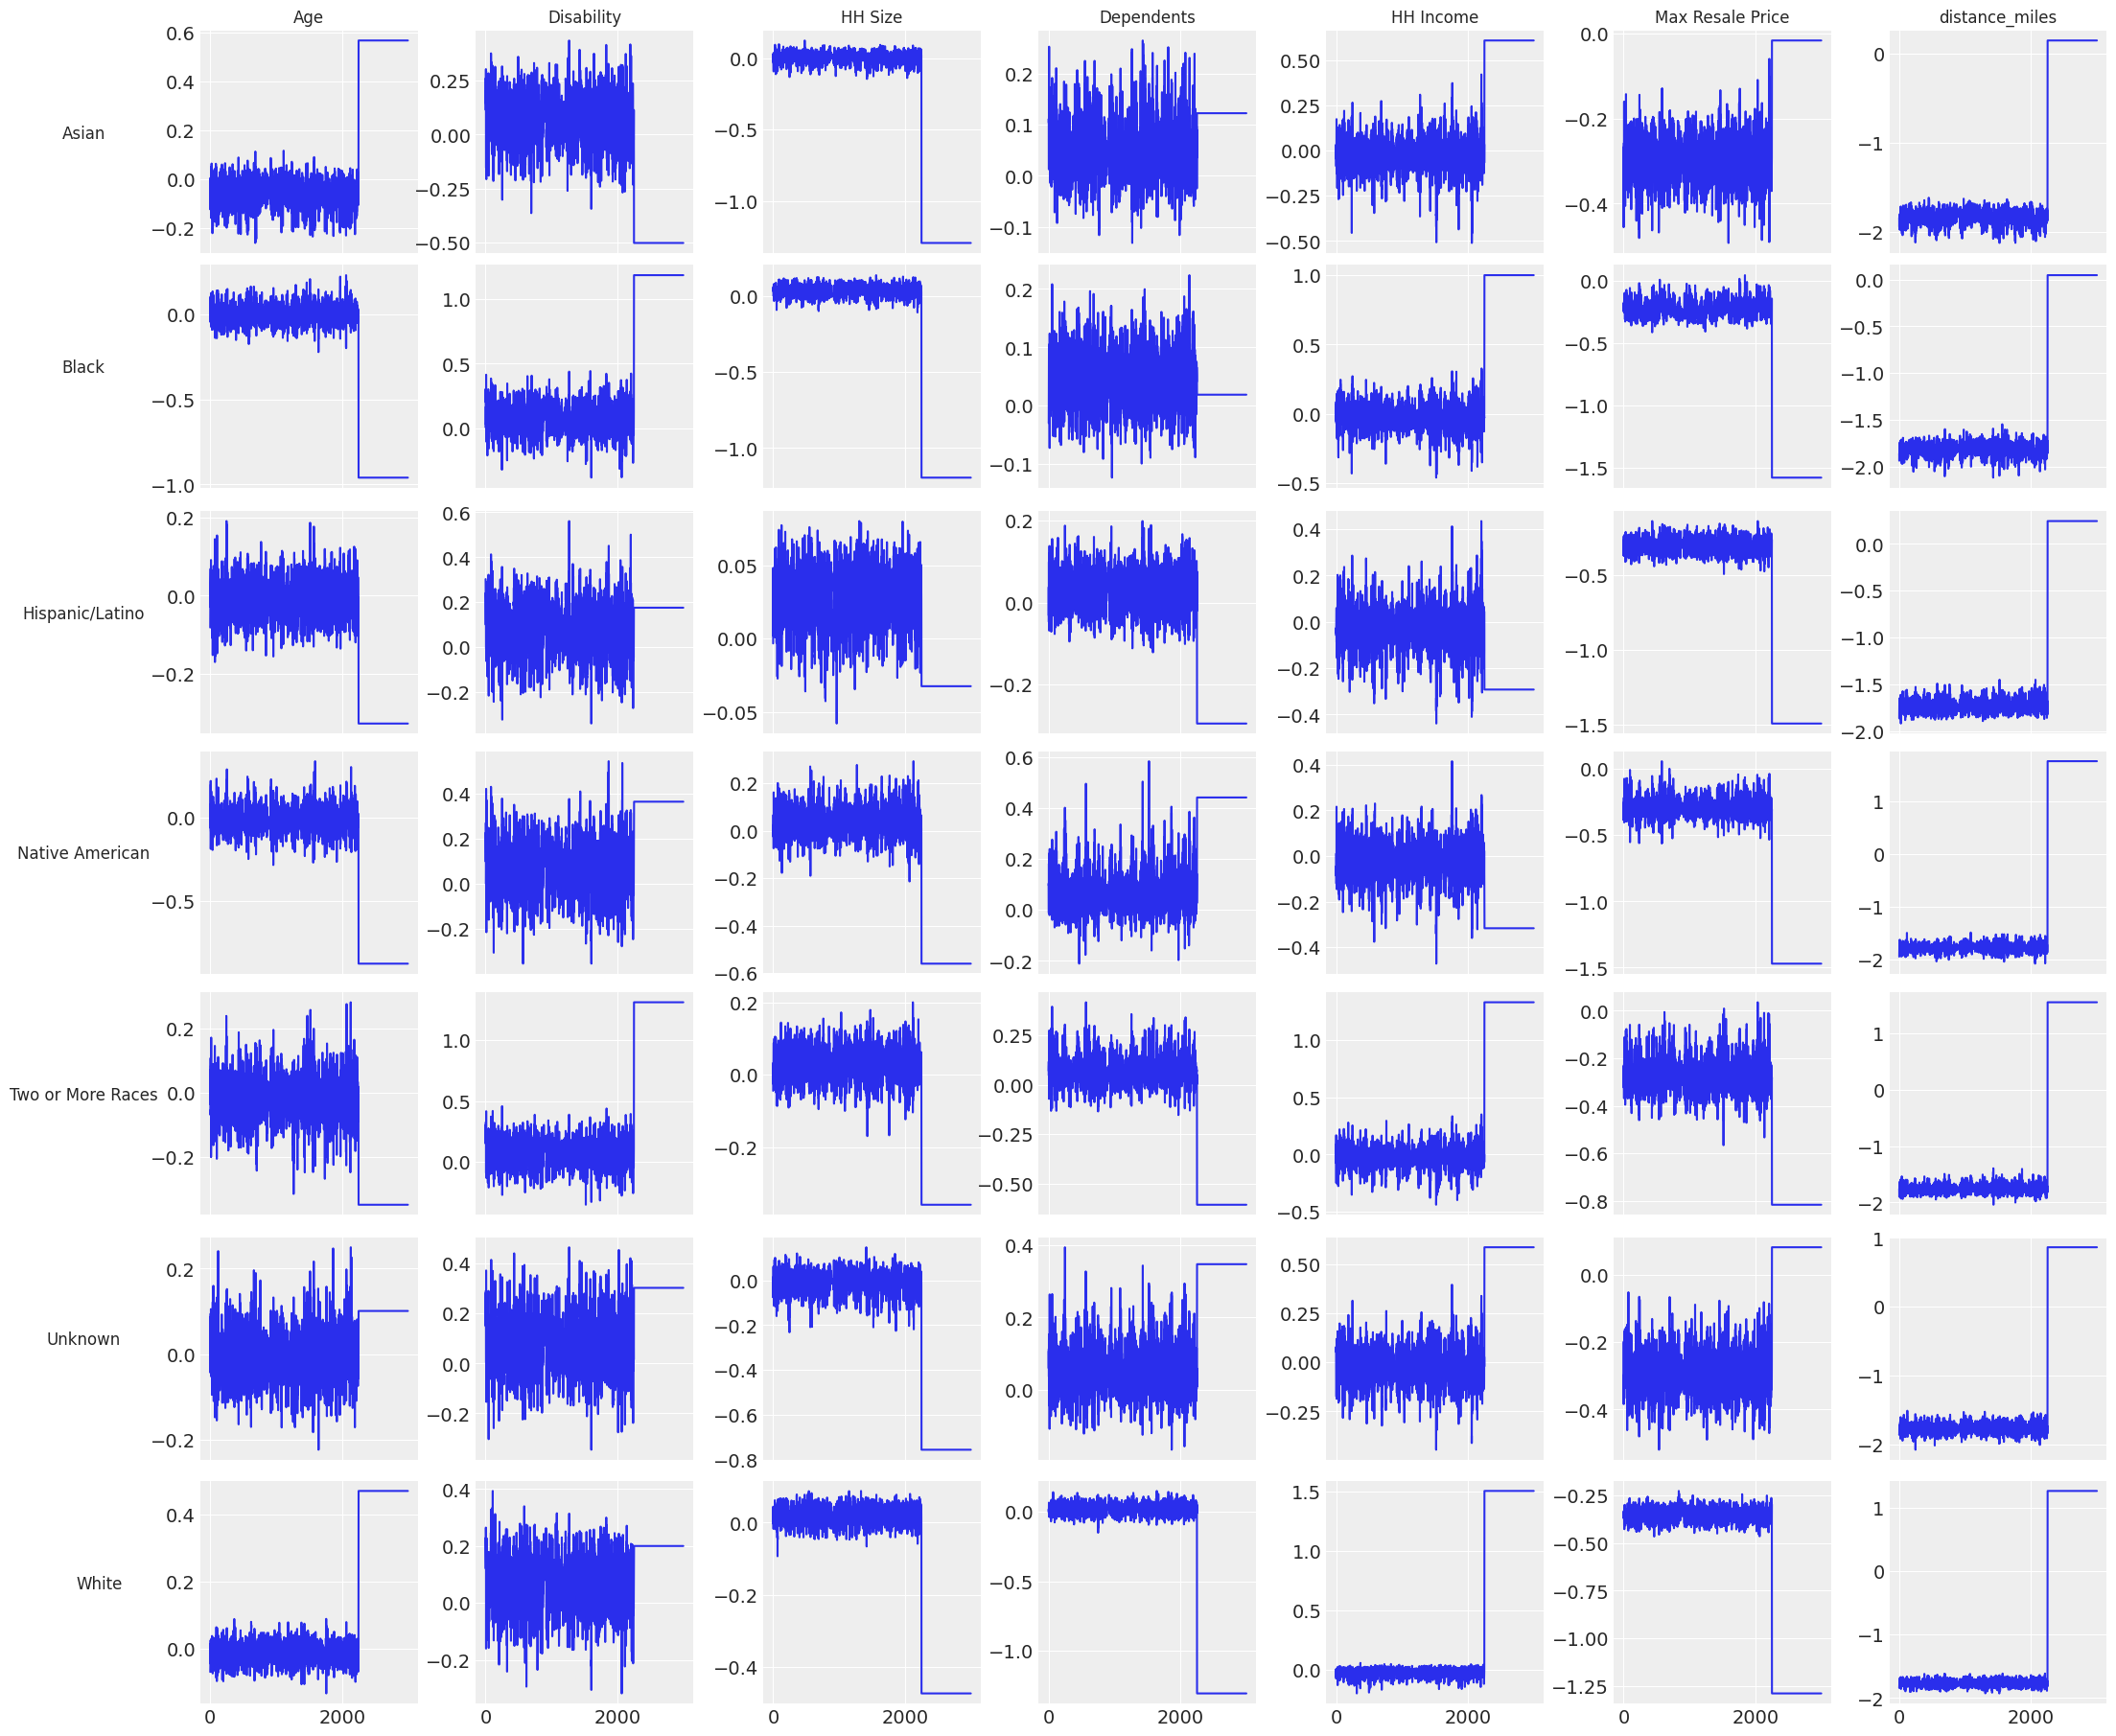

In [54]:
# Check trace plots for beta

races = ['Asian', 'Black', 'Hispanic/Latino', 'Native American',
         'Two or More Races', 'Unknown', 'White']

features = ['Age', 'Disability', 'HH Size', 'Dependents',
            'HH Income', 'Max Resale Price', 'distance_miles']

fig, axs = plt.subplots(
    nrows=len(races), ncols=len(features),
    figsize=(22, 18),
    sharex=True, sharey=False
)

plt.subplots_adjust(hspace=0.6, wspace=0.4)

for r in range(len(races)):
    for c in range(len(features)):
        vals = beta_posterior[r, c, :]

        axs[r, c].plot(vals)

# row/col labels
for r, race in enumerate(races):
    axs[r, 0].set_ylabel(race, fontsize=12, rotation=0, labelpad=50)
for c, feat in enumerate(features):
    axs[0, c].set_title(feat, fontsize=12)

plt.show()

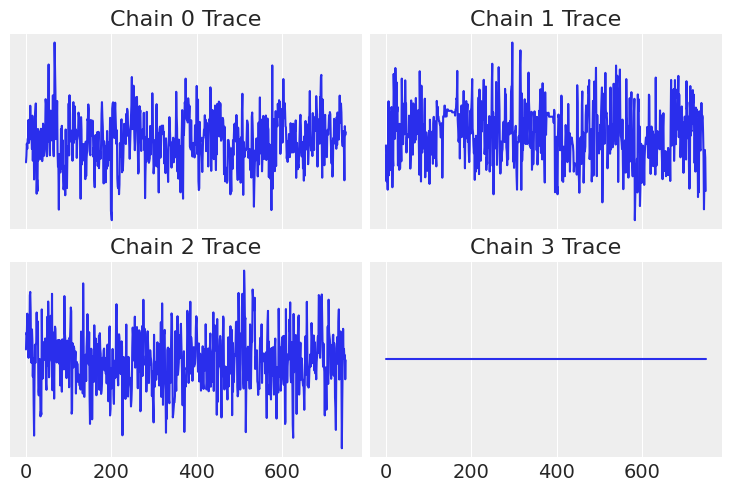

In [51]:
# odd sticky behavior starting around 750 samples from the end

fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True)

axs = axs.flatten()

for chain in range(4):
    axs[chain].plot(idata.posterior.gamma.values[chain, :])
    axs[chain].set_title(f"Chain {chain} Trace")
    axs[chain].set_yticks([])

plt.show()


In [55]:
# fourth chain degenerate-- remove!!
beta_posterior = beta_posterior[:,:,:-750]

In [68]:

fig, axs = plt.subplots(
    nrows=len(races), ncols=len(features),
    figsize=(22, 18),
    sharex=False, sharey=False, dpi=600
)

plt.subplots_adjust(hspace=0.6, wspace=0.4)

for r in range(len(races)):
    for c in range(len(features)):
        vals = beta_posterior[r, c, :]

        axs[r, c].hist(vals, density=True, bins=30)

        axs[r, c].axvline(0, color="red")

        # remove extra ticks
        axs[r, c].set_yticks([])
        
        if r != (len(races)-1):
            axs[r, c].set_xticks([])


        axs[r, c].tick_params(labelsize=8)

        if c == (len(features)-1):
            axs[r, c].set_xlim(-2.2, -1.2)
        else:
            axs[r, c].set_xlim(-0.45, 0.45)

# row/col labels
for r, race in enumerate(races):
    axs[r, 0].set_ylabel(race, fontsize=12, rotation=0, labelpad=50)
for c, feat in enumerate(features):
    axs[0, c].set_title(feat, fontsize=12)


plt.show()


/var/folders/q9/vssjztfs6gd47qy2w2t2f0t80000gn/T/ipykernel_41933/2041466660.py:7: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.6, wspace=0.4)


In [81]:
means.mean()

np.float64(-1.7788149761808714)

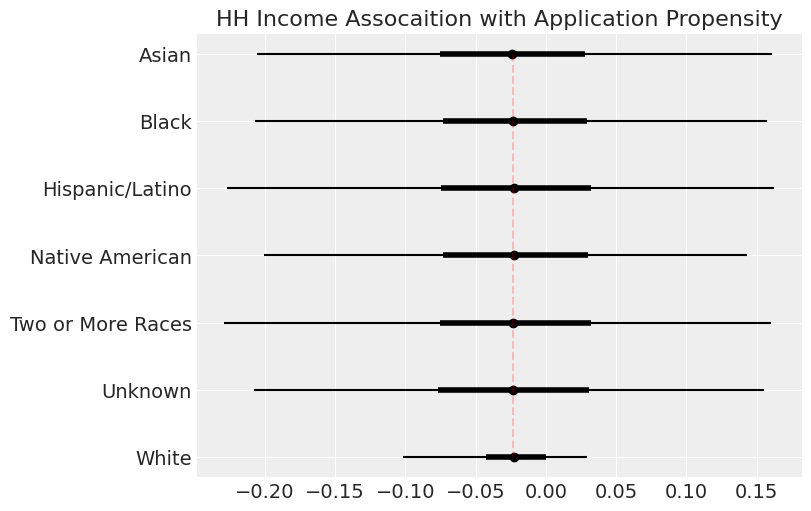

<Figure size 4320x2880 with 0 Axes>

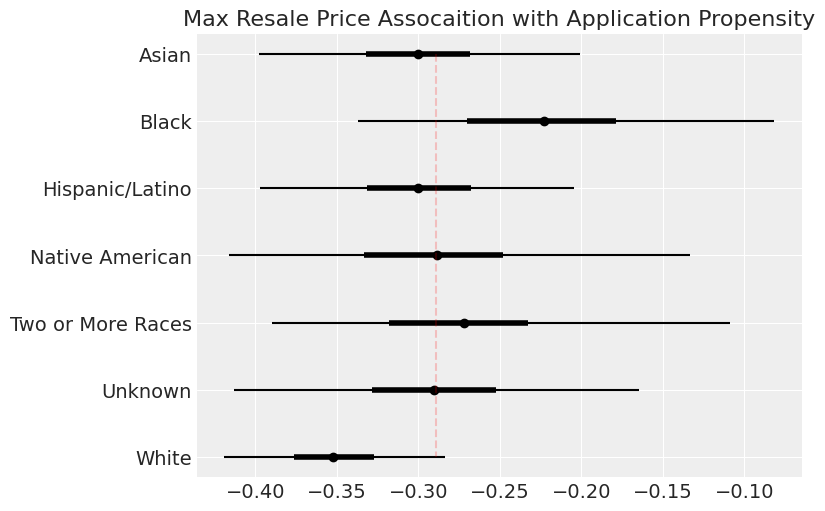

<Figure size 4320x2880 with 0 Axes>

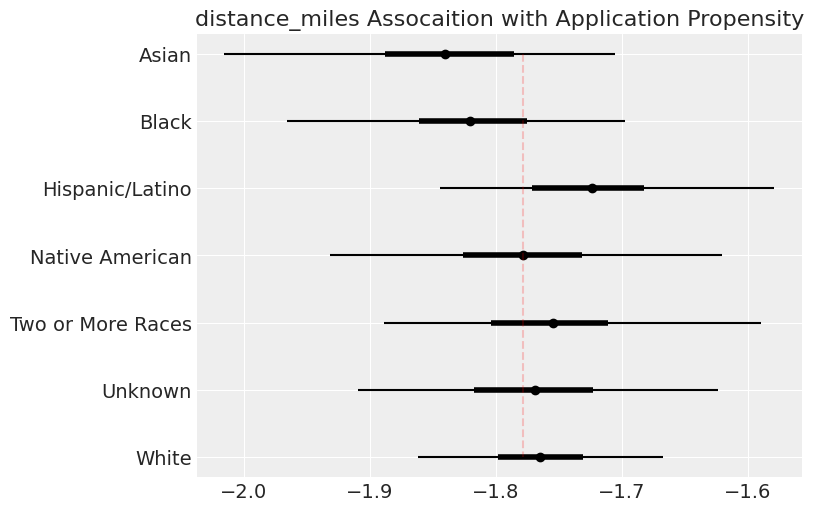

<Figure size 4320x2880 with 0 Axes>

In [ ]:
for feat in [4, 5, 6]:

    vals = beta_posterior[:, feat, :]

    means = vals.mean(axis=1)
    ci50 = np.percentile(vals, [25, 75], axis=1)
    ci95 = np.percentile(vals, [2.5, 97.5], axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))

    y = np.arange(len(races))

    ax.hlines(y, ci95[0], ci95[1], color='black')
    ax.hlines(y, ci50[0], ci50[1], color='black', linewidth=4)
    ax.plot(means, y, 'o', color='black')

    ax.vlines(means.mean(), ymin=0, ymax=6, color="red", ls="--", alpha=0.2)

    ax.set_yticks(y)
    ax.set_yticklabels(races)
    ax.invert_yaxis()
    plt.title(f"{features[feat]} Assocaition with Application Propensity")
    plt.figure(dpi=600)
    plt.show()

In [160]:
def compare_race_effect(
    beta_posterior,
    race_name,
    feature_name,
    races,
    features, 
    ax=None
):
    """
    Computes posterior distribution of how much stronger/weaker a race's
    sensitivity to a feature is, compared to the average across races.
    """

    r_idx = races.index(race_name)
    f_idx = features.index(feature_name)

    # race-specific posterior samples (shape: samples,)
    beta_r = beta_posterior[r_idx, f_idx, :]

    # average across all races (shape: samples,)
    beta_avg = beta_posterior[:, f_idx, :].mean(axis=0)

    # posterior distribution of differences
    diff = beta_r - beta_avg

    if ax==None:
        plt.hist(diff, bins=30, density=True)
        plt.vlines(0, color='red', ls='--', ymin=0, ymax=5)
        plt.title(f'{feature_name}: Posterior Difference for {race_name}\nMean: {diff.mean():.2f}')
        plt.show()
    else:
        ax.hist(diff, bins=30, density=True)
        ax.axvline(0, color='red', ls='--')
        ax.set_title(f'{feature_name}: Posterior Difference for {race_name}\nMean: {diff.mean():.2f}')


    summary = {
        "posterior_mean": diff.mean(),
        "hdi_2.5": np.percentile(diff, 2.5),
        "hdi_97.5": np.percentile(diff, 97.5)
    }

    return summary
